# Thesis Baseline Setup

This notebook documents the workflow for the thesis baseline on xBD/xView2 using a building-level classification pipeline.

---

## Core Principle

- Preprocessing and model training run directly in Python
- Notebook is used for:
  - Data inspection
  - Sanity checks
  - Training control
  - Evaluation
  - Visualization

The official xView2 Docker pipeline is not used as the main experimental setup, because the thesis isolates the damage classification task from localization by using ground truth building polygons.

---

## Required Data

Download and place on Desktop:

- `train`
- `test`
- `hold`

These contain:
- images
- labels

---

## Main Experimental Design

The thesis does not use the original end to end competition pipeline as the primary method.

Instead, the pipeline is:

1. Read ground truth polygons from label JSON files
2. Build a building-level metadata table
3. Extract pre/post building crops
4. Stack pre and post crops into 6-channel tensors
5. Train a ResNet50-based classifier on damage labels

This removes localization as a confounding factor and isolates the classification task.

---

## Required External Apps

- `miniconda` or another Python environment manager


## Create Environment

```bash
conda create -n thesis_xview python=3.10
conda activate thesis_xview

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached libtiff-0.4.2.tar.gz (129 kB)
     |████████████████████████████████| 948 kB 390 kB/s eta 0:00:01
     |████████████████████████████████| 323 kB 469 kB/s eta 0:00:01
     |████████████████████████████████| 1.4 MB 2.7 MB/s eta 0:00:01
  Using cached imantics-0.1.12-py3-none-any.whl
     |████████████████████████████████| 1.4 MB 1.1 MB/s eta 0:00:01
  distutils: /private/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/pip-build-env-42t6_521/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/pip-build-env-42t6_521/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/pip-build-env-42t6_521/normal'
  distutils: /private/var/folders/bs/rzk6qg1902vgdlp6h22t8bq4000

In [2]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


# Training, Validation, and Class Weighting Strategy

## 1. Data Splits: Train, Test, and Hold

The dataset is divided into three distinct subsets, each with a specific role in the machine learning pipeline:

### Train Split
The **training set** is used to learn the model parameters. During this phase, the model updates its weights based on the input data and corresponding labels.

### Test Split
The **test set** is used during training to evaluate model performance after each epoch. It serves as a **validation set** for:

- monitoring learning progress  
- selecting the best model (e.g., best epoch)  
- comparing configurations or hyperparameters  

Importantly, the model does **not learn from the test set**. It is only used for evaluation.

### Hold Split
The **holdout set** is used for the **final evaluation** after training is complete. It provides an unbiased estimate of model performance because:

- it is not used during training  
- it is not used for model selection  

This separation ensures that reported results reflect true generalization.

---

### Summary of Roles

| Split | Purpose |
|------|--------|
| Train | Learn model parameters |
| Test | Model selection and monitoring |
| Hold | Final unbiased evaluation |

---

## 2. Class Imbalance and Class Weights

### Problem: Imbalanced Data

In the dataset, the distribution of damage classes is highly imbalanced. For example:

- "no-damage" appears far more frequently  
- "minor", "major", and "destroyed" are much less common  

Without correction, the model would tend to predict the majority class ("no-damage") to minimize loss, leading to poor performance on rare but important damage categories.

---

### Solution: Class-Weighted Loss

To address this, a **class-weighted cross-entropy loss** is used.

Each class is assigned a weight:

```text
[0.3402, 2.6667, 2.8210, 3.0202]

In [ ]:
import sys
!{sys.executable} model/classification_baseline.py

Loading data...

Split sizes:
split
train    159793
test      53850
hold      53137
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       117425
minor-damage     14980
major-damage     14161
destroyed        13227
Name: count, dtype: int64

Using device: mps

Using class weights: [0.34020224 2.6667724  2.8210049  3.0202048 ]

Starting training...
Epoch 1/10: 100%|██████████████| 4994/4994 [36:52<00:00,  2.26it/s, loss=1.1275]
Epoch 01 | Train Loss: 0.8313 | Test Loss: 0.6384 | Test F1: 0.6130 | Time: 39.10 min
Epoch 2/10: 100%|██████████████| 4994/4994 [24:19<00:00,  3.42it/s, loss=0.5993]
Epoch 02 | Train Loss: 0.6656 | Test Loss: 0.6451 | Test F1: 0.6329 | Time: 78.95 min
Epoch 3/10: 100%|██████████████| 4994/4994 [33:42<00:00,  2.47it/s, loss=0.2095]
Epoch 03 | Train Loss: 0.5724 | Test Loss: 0.5816 | Test F1: 0.6539 | Time: 36.07 min
Epoch 4/10: 100%|██████████████| 4994/4994 [24:29<00:00,  3.40it/s, loss=0.4315]
Epoch 04 | Train Loss: 0.4718 | Test Loss

# Model Performance Analysis and Interpretation

## 1. Training Dynamics

The training process exhibits a clear pattern of convergence followed by overfitting. Training loss decreases consistently across epochs, while test loss initially decreases and then begins to increase after approximately the third epoch.

The macro F1 score on the test set peaks at **epoch 3 (0.6539)** and does not improve significantly afterward. This indicates that the model achieves its best generalization performance early in training, after which it begins to overfit the training data.

This behavior suggests that:

- the model has sufficient capacity to fit the dataset
- prolonged training does not improve generalization
- early stopping would be an effective strategy in this setting

---

## 2. Overall Performance

The final performance of the model is summarized below:

| Split | Macro F1 |
|------|--------|
| Test | 0.6539 |
| Hold | 0.6669 |

The slightly higher performance on the holdout set indicates that:

- the model generalizes well beyond the test set
- there is no evidence of overfitting to the test split
- the dataset splits are consistent and representative

Overall, a macro F1 score in the range of **0.65–0.67** represents a strong baseline for this task using a standard ResNet50 architecture without extensive hyperparameter tuning.

---

## 3. Class-wise Performance

The model exhibits varying performance across damage categories.

### No-damage

- F1 score: high (≈ 0.87–0.88)
- strong precision and recall

This is expected due to the high frequency and clear visual characteristics of this class.

---

### Minor and Major Damage

- F1 scores: moderate (≈ 0.53–0.58)
- lower precision compared to recall

These classes are more difficult to distinguish due to:

- subtle visual differences
- ambiguity between damage levels
- overlapping feature representations

---

### Destroyed

- F1 score: relatively strong (≈ 0.67–0.69)

This class benefits from more distinct visual features, making it easier for the model to identify.

---

## 4. Precision–Recall Trade-off

A notable pattern emerges across all damage classes:

- **high recall**
- **lower precision**

This indicates that the model tends to **over-predict damage**, classifying uncertain cases as damaged rather than undamaged.

This behavior is directly influenced by the use of class-weighted loss.

---

## 5. Effect of Class Weights

Class weights were applied to address the strong imbalance in the dataset, where the "no-damage" class dominates.

By assigning higher weights to minority classes, the model is encouraged to prioritize correct classification of damaged buildings.

This leads to:

### Positive effects

- improved recall for damage classes  
- better detection of rare events  
- more balanced class performance  

### Side effects

- increased false positives for damage  
- confusion between adjacent damage levels  
- reduced precision  

This trade-off is expected and reflects a deliberate modeling choice to prioritize detection of damage over conservative classification.

---

## 6. Generalization to Holdout Data

The model performs slightly better on the holdout set than on the test set.

This suggests that:

- the model does not overfit the validation process  
- learned features generalize across different disaster scenarios  
- the evaluation protocol is robust  

This is an important indicator of model reliability.

---

## 7. Limitations

Despite strong baseline performance, several limitations remain:

- difficulty distinguishing between intermediate damage levels  
- sensitivity to class imbalance  
- overfitting after early epochs  
- reliance on bounding box crops without fine-grained localization  

These limitations are consistent with known challenges in post-disaster damage classification tasks.

These findings provide a solid foundation for further experimentation and model refinement.

## Confusion Matrix

Using prediction files from:
/Users/paolo/Desktop/training_outputs/baseline_resnet50


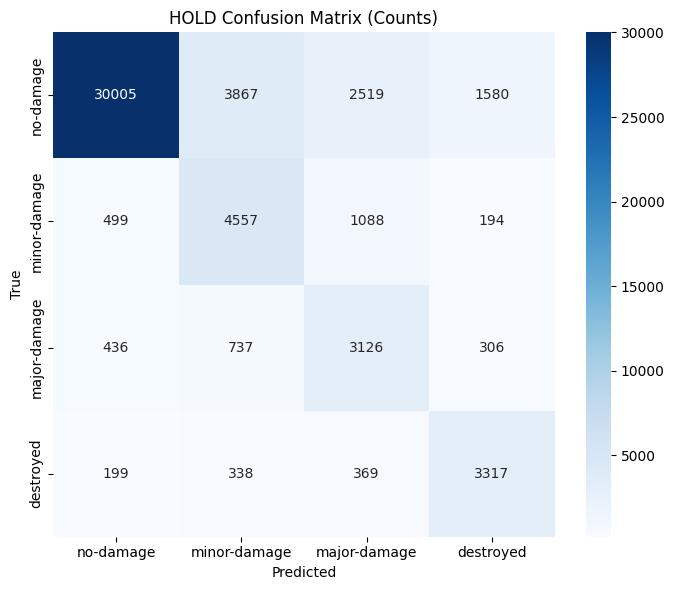

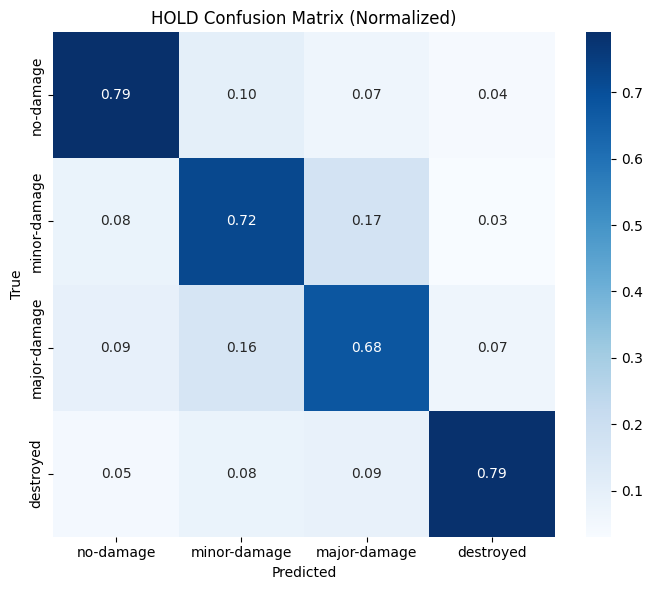

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# =========================
# Configuration
# =========================

split = "hold"

labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]

PROJECT_ROOT = Path.cwd()

candidate_paths = [
    PROJECT_ROOT / "training_outputs" / "baseline_resnet50",
    Path.home() / "Desktop" / "training_outputs" / "baseline_resnet50",
    Path.home() / "Documents" / "GitHub" / "xView2_baseline_thesis" / "training_outputs" / "baseline_resnet50",
]

BASE_PATH = None

for path in candidate_paths:
    y_true_path = path / f"{split}_targets.npy"
    y_pred_path = path / f"{split}_preds.npy"

    if y_true_path.exists() and y_pred_path.exists():
        BASE_PATH = path
        break

if BASE_PATH is None:
    searched = "\n".join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        f"Could not find {split}_targets.npy and {split}_preds.npy.\n\n"
        f"Searched in:\n{searched}"
    )

print(f"Using prediction files from:\n{BASE_PATH}")

# =========================
# Load predictions
# =========================

y_true = np.load(BASE_PATH / f"{split}_targets.npy")
y_pred = np.load(BASE_PATH / f"{split}_preds.npy")

# =========================
# Raw confusion matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title(f"{split.upper()} Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =========================
# Normalized confusion matrix
# =========================

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title(f"{split.upper()} Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

The normalized confusion matrix provides insight into the model’s class-wise prediction behavior.

### Overall Performance

The model shows strong performance along the diagonal, indicating good classification accuracy across all classes. In particular:

- **no-damage** and **destroyed** achieve the highest accuracy (≈ 0.79)
- **minor-damage** and **major-damage** show slightly lower accuracy (≈ 0.72 and 0.68)

This confirms that the model performs best on visually distinct classes.

---

### Error Patterns

The main misclassifications occur between adjacent damage levels:

- **minor-damage → major-damage (0.17)**
- **major-damage → minor-damage (0.16)**

This indicates difficulty in distinguishing intermediate levels of damage, likely due to subtle visual differences.

Additionally:

- some **no-damage** instances are predicted as **minor-damage (0.10)**
- some **major-damage** instances are predicted as **destroyed (0.07)**

These errors suggest a tendency to **overestimate damage severity**.

---

### Model Bias

The confusion matrix reveals a consistent pattern:

- relatively high recall for damaged classes  
- increased confusion toward more severe categories  

This behavior aligns with the use of **class-weighted loss**, which encourages the model to prioritize detecting damage over conservative predictions.

---

### Summary

The confusion matrix confirms that:

- the model effectively distinguishes between **no damage** and **severe damage**
- most errors occur between **adjacent damage categories**
- the model exhibits a **bias toward predicting higher damage levels**

These findings are consistent with the overall performance metrics and highlight the inherent difficulty of fine-grained damage classification.

## Sanity Check: Verification of ResNet50-Based Architecture

Before proceeding with full training and experimentation, a structural sanity check was performed to ensure that the implemented model correctly corresponds to a ResNet50 architecture adapted to the specific task.


In [3]:
import torch
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

class ResNet50SixChannel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        weights = ResNet50_Weights.IMAGENET1K_V2
        self.backbone = resnet50(weights=weights)

        old_conv = self.backbone.conv1
        new_conv = nn.Conv2d(
            in_channels=6,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:, :, :] = old_conv.weight

        self.backbone.conv1 = new_conv
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

model = ResNet50SixChannel(num_classes=4)

print(model.backbone.conv1)
print(model.backbone.fc)

total_params = sum(p.numel() for p in model.parameters())
print("Total params:", total_params)

Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=2048, out_features=4, bias=True)
Total params: 23525636




The structural sanity check confirms that the implemented model correctly corresponds to a ResNet50-based architecture adapted for the task.

### Key Results

- **Input Layer:**  
  `Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))`  
  → Confirms successful adaptation from 3 to **6 input channels**, enabling joint processing of pre- and post-disaster imagery.

- **Output Layer:**  
  `Linear(in_features=2048, out_features=4)`  
  → Confirms correct modification of the classifier head for **4 damage classes**, while preserving the standard ResNet50 feature dimension.

- **Parameter Count:**  
  ~23.5 million parameters  
  → Consistent with a **ResNet50-scale model**, accounting for minor changes due to input/output layer modifications.

### Interpretation

These results verify that:

- The backbone architecture remains **ResNet50**
- The model is correctly configured for the **6-channel input representation**
- The classification head matches the **task-specific output space**

### Conclusion

The sanity check confirms that the model is structurally valid and correctly adapted, ensuring that subsequent training and evaluation are performed on a properly specified ResNet50-based architecture.
```


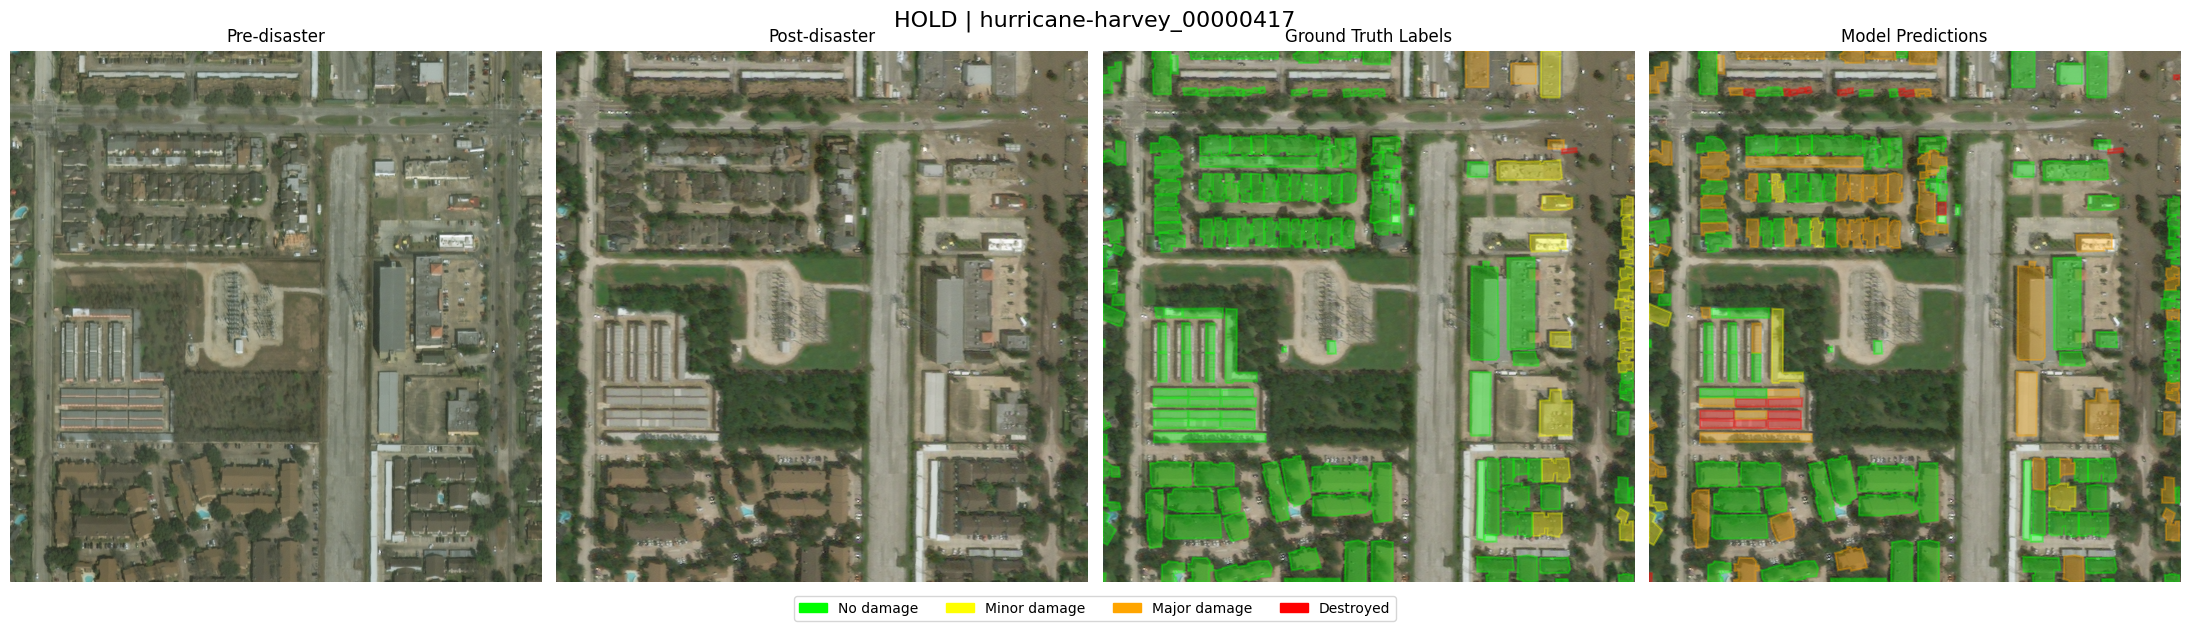

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

BASE_DIR = Path.home() / "Desktop"
CSV_PATH = BASE_DIR / "processed" / "buildings_all_with_crops.csv"
OUTPUT_DIR = BASE_DIR / "training_outputs" / "baseline_resnet50"

split = "hold"  # "test" or "hold"

LABELS = ["no-damage", "minor-damage", "major-damage", "destroyed"]
COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

df = pd.read_csv(CSV_PATH)
split_df = df[df["split"] == split].copy().reset_index(drop=True)

preds = np.load(OUTPUT_DIR / f"{split}_preds.npy")
targets = np.load(OUTPUT_DIR / f"{split}_targets.npy")

split_df["pred_idx"] = preds
split_df["true_idx"] = targets
split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])


image_id = split_df["image_id"].value_counts().index[69]

img_df = split_df[split_df["image_id"] == image_id].copy()

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )
        ax.add_patch(patch)

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster")
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster")
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels"
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Model Predictions"
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05)
)

plt.suptitle(f"{split.upper()} | {image_id}", fontsize=16)
plt.tight_layout()
plt.show()